In [1]:
# as bibliotecas e os importes que irei usar
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt

tf.random.set_seed(1)
print("GPUs disponíveis: ", len(tf.config.list_physical_devices('GPU')))

GPUs disponíveis:  1


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() # carrega os codigos numericos

In [3]:
dataset = np.concatenate([x_train, x_test], axis=0) # une treino e teste
dataset = np.expand_dims(dataset, -1).astype("float32") / 255 # normaliza os dados

In [4]:
BATCH_SIZE = 64

dataset = np.reshape(dataset, (-1, 28, 28, 1)) # formata para as camadas
dataset = tf.data.Dataset.from_tensor_slices(dataset) # converte para objeto
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE) # embaralha e agrupa em lotes

In [5]:
NOISE_DIM = 150 # dimensao

# recebe e aprende a gerar codigos
generator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(NOISE_DIM,)),
  layers.Dense(7*7*256),
  layers.Reshape(target_shape=(7, 7, 256)),
  layers.Conv2DTranspose(256, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2DTranspose(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,894,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,780,417 (10.61 MB)

 Trainable params: 2,780,417 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# taxas diferentes para falsificador e detector
optimizerG = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.5)
optimizerD = keras.optimizers.Adam(learning_rate=0.00003, beta_1=0.5)

lossFn = keras.losses.BinaryCrossentropy(from_logits=True) # real ou falsificado
gAccMetric = tf.keras.metrics.BinaryAccuracy() # acuracia do falsificador
dAccMetric = tf.keras.metrics.BinaryAccuracy() # acuracia do detector

In [7]:
@tf.function
def trainDStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM)) # ruido alimenta o falsificador

  # codigos reais recebem rotulo
  y_true = tf.concat([tf.ones(batchSize, 1), tf.zeros(batchSize, 1)], axis=0)

  with tf.GradientTape() as tape:
    fake = generator(noise) # falsificador gera codigos falsos
    x = tf.concat([data, fake], axis=0) # detector analisa reais e falsos juntos
    y_pred = discriminator(x)
    discriminatorLoss = lossFn(y_true, y_pred)

  grads = tape.gradient(discriminatorLoss, discriminator.trainable_weights)
  optimizerD.apply_gradients(zip(grads, discriminator.trainable_weights))
  dAccMetric.update_state(y_true, y_pred)

  return {"discriminator_loss": discriminatorLoss, "discriminator_accuracy": dAccMetric.result()}

In [8]:
@tf.function
def trainGStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))
  y_true = tf.ones(batchSize, 1) # falsificador quer ser classificado como real

  with tf.GradientTape() as tape:
    y_pred = discriminator(generator(noise))
    generatorLoss = lossFn(y_true, y_pred) # perda baseada em quantas vezes foi pego

  grads = tape.gradient(generatorLoss, generator.trainable_weights)
  optimizerG.apply_gradients(zip(grads, generator.trainable_weights))
  gAccMetric.update_state(y_true, y_pred)

  return {"generator_loss": generatorLoss, "generator_accuracy": gAccMetric.result()}

In [9]:
# o detector que identifica falsificacoes
discriminator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(28, 28, 1)),
  layers.Conv2D(64, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2D(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Flatten(),
  layers.Dense(1, activation="sigmoid") # probabilidade de ser real
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Epoca:0, Perda G:1.2999, Perda D:0.3891
Epoca:1, Perda G:0.9484, Perda D:0.5177
Epoca:2, Perda G:0.8530, Perda D:0.5949
Epoca:3, Perda G:0.8084, Perda D:0.6256
Epoca:4, Perda G:0.8131, Perda D:0.6168
Epoca:5, Perda G:0.8423, Perda D:0.5969
Epoca:6, Perda G:0.8423, Perda D:0.5951
Epoca:7, Perda G:0.8557, Perda D:0.5801
Epoca:8, Perda G:0.8677, Perda D:0.5716
Epoca:9, Perda G:0.9223, Perda D:0.5406
Epoca:10, Perda G:0.9660, Perda D:0.5183
Epoca:11, Perda G:0.9962, Perda D:0.5064
Epoca:12, Perda G:1.0383, Perda D:0.4855
Epoca:13, Perda G:1.0702, Perda D:0.4742
Epoca:14, Perda G:1.0986, Perda D:0.4659
Epoca:15, Perda G:1.1360, Perda D:0.4514
Epoca:16, Perda G:1.1299, Perda D:0.4572
Epoca:17, Perda G:1.1278, Perda D:0.4610
Epoca:18, Perda G:1.1219, Perda D:0.4662
Epoca:19, Perda G:1.0947, Perda D:0.4830
Epoca:20, Perda G:1.0689, Perda D:0.4977
Epoca:21, Perda G:1.0383, Perda D:0.5158
Epoca:22, Perda G:1.0076, Perda D:0.5344
Epoca:23, Perda G:0.9749, Perda D:0.5546
Epoca:24, Perda G:0.9481, 

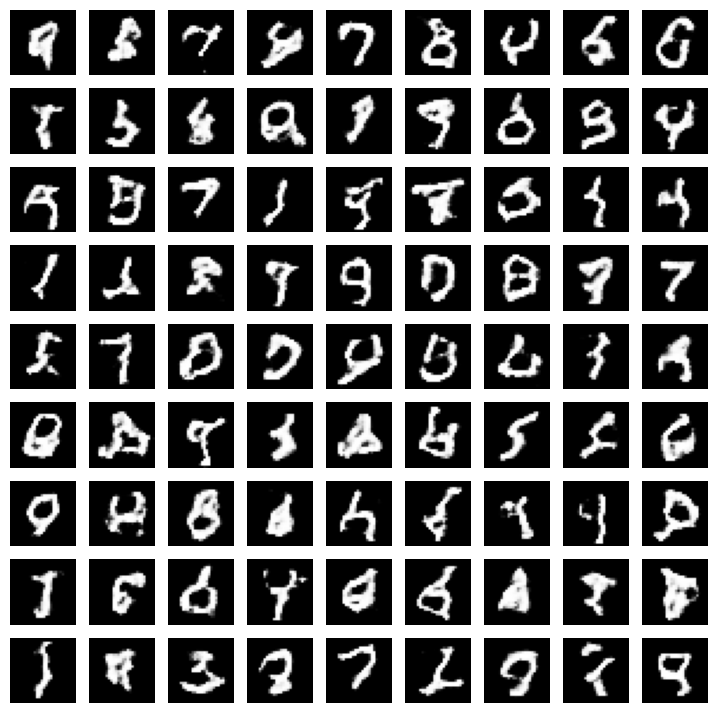

In [10]:
def plotarImagens(model):
    # usando o tensorFlow para gerar o ruido para não travar o grafo do Keras
    images = model(tf.random.normal(shape=(81, NOISE_DIM)))

    plt.figure(figsize=(9, 9))
    for i, image in enumerate(images):
        plt.subplot(9, 9, i+1)
        plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
        plt.axis('off')

    plt.show()

# treina o falsificador e o detector ao longo das épocas
for epoch in range(30):

    dLossSum = 0
    gLossSum = 0
    dAccSum = 0
    gAccSum = 0
    cnt = 0

    for batch in dataset:

        # passo de treino do detector
        dLoss = trainDStep(batch)
        dLossSum += dLoss['discriminator_loss']
        dAccSum += dLoss['discriminator_accuracy']

        # passo de treino do falsificador
        gLoss = trainGStep(batch)
        gLossSum += gLoss['generator_loss']
        gAccSum += gLoss['generator_accuracy']

        cnt += 1

    # printa o progresso de cada época
    print("Epoca:{}, Perda G:{:0.4f}, Perda D:{:0.4f}".format(
        epoch, gLossSum/cnt, dLossSum/cnt,
        100 * gAccSum/cnt, 100 * dAccSum/cnt
    ))

# Fora en um laço para as 30 epocas
plotarImagens(generator)